In [1]:
# CELDA 1: Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
import psycopg2
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")

✅ Librerías importadas correctamente
   pandas      2.2.2
   numpy       1.26.4
   seaborn     0.13.2


In [3]:
# CELDA 2: Carga de datos y variable objetivo
conn = psycopg2.connect(
    host='localhost', port=5432,
    database='divisas_db', user='etl_user', password='etl1234'
)

df = pd.read_sql("""
    SELECT moneda_destino, tasa_cambio, inversa, 
           variacion_pct, volatilidad_7d,
           fecha_extraccion
    FROM tasas_cambio
    WHERE fecha_actualizacion_api = 'simulado'
    ORDER BY fecha_extraccion ASC
""", conn)
conn.close()

df['fecha_extraccion'] = pd.to_datetime(df['fecha_extraccion'])
df['dia'] = (df['fecha_extraccion'] - df['fecha_extraccion'].min()).dt.days

# Variable objetivo binaria: 1 si la tasa subió, 0 si bajó
df['sube_tasa'] = (df['variacion_pct'] > 0).astype(int)

print(f"✅ Datos cargados: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n🎯 Balance de la variable objetivo:")
print(f"   Tasa subió  (1): {df['sube_tasa'].sum():,}  ({df['sube_tasa'].mean()*100:.1f}%)")
print(f"   Tasa bajó   (0): {(df['sube_tasa']==0).sum():,}  ({(df['sube_tasa']==0).mean()*100:.1f}%)")
print(f"\n📋 Monedas: {df['moneda_destino'].unique()}")
df.head()


✅ Datos cargados: 1,000 filas × 8 columnas

🎯 Balance de la variable objetivo:
   Tasa subió  (1): 516  (51.6%)
   Tasa bajó   (0): 484  (48.4%)

📋 Monedas: ['EUR' 'COP' 'GBP' 'JPY' 'BRL' 'MXN' 'CAD' 'AUD']


,moneda_destino,tasa_cambio,inversa,variacion_pct,volatilidad_7d,fecha_extraccion,dia,sube_tasa
0,EUR,0.839169,1.191655,-2.444907,0.021031,2025-12-19 00:16:59.756857,0,0
1,COP,3766.745886,0.000265,0.363857,13.655886,2025-12-19 00:16:59.756857,0,1
2,GBP,0.740860,1.349783,-0.475605,0.003540,2025-12-19 00:16:59.756857,0,0
3,JPY,155.793719,0.006419,-1.333934,2.106281,2025-12-19 00:16:59.756857,0,0
4,BRL,5.177812,0.193132,0.248053,0.012812,2025-12-19 00:16:59.756857,0,1


In [6]:
# CELDA 3: Preparación de features y splits
# Quitamos variacion_pct porque define directamente sube_tasa
FEATURES_EXT = ['tasa_cambio', 'inversa', 'volatilidad_7d', 'dia', 'moneda_cod']

df['moneda_cod'] = pd.factorize(df['moneda_destino'])[0]

X_ext = df[FEATURES_EXT]
y = df['sube_tasa']

splits = [
    {'nombre': 'Split 80/20', 'test_size': 0.20},
    {'nombre': 'Split 70/30', 'test_size': 0.30},
    {'nombre': 'Split 60/40', 'test_size': 0.40},
]

print("✅ Features preparados")
print(f"   X shape : {X_ext.shape}")
print(f"   y shape : {y.shape}")
print(f"\n📋 Features usados: {FEATURES_EXT}")
print(f"\n📊 Distribución objetivo:")
print(y.value_counts())

✅ Features preparados
   X shape : (1000, 5)
   y shape : (1000,)

📋 Features usados: ['tasa_cambio', 'inversa', 'volatilidad_7d', 'dia', 'moneda_cod']

📊 Distribución objetivo:
sube_tasa
1    516
0    484
Name: count, dtype: int64


In [7]:
# CELDA 4: Árbol de Decisión — 3 splits
resultados_arbol = []

for s in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X_ext, y, test_size=s['test_size'], random_state=42
    )
    
    modelo = DecisionTreeClassifier(class_weight='balanced', random_state=42)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    resultados_arbol.append({
        'nombre'     : s['nombre'],
        'train_size' : len(X_train),
        'test_size'  : len(X_test),
        'accuracy'   : accuracy_score(y_test, y_pred),
        'precision'  : precision_score(y_test, y_pred),
        'recall'     : recall_score(y_test, y_pred),
        'f1'         : f1_score(y_test, y_pred),
        'roc_auc'    : roc_auc_score(y_test, y_prob),
        'modelo'     : modelo,
        'X_test'     : X_test,
        'y_test'     : y_test,
        'y_pred'     : y_pred,
        'y_prob'     : y_prob,
    })

# Tabla resumen
resumen_arbol = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'],  4),
    'Precision'      : round(r['precision'], 4),
    'Recall'         : round(r['recall'],    4),
    'F1-Score'       : round(r['f1'],        4),
    'ROC-AUC'        : round(r['roc_auc'],   4),
} for r in resultados_arbol]).set_index('Split')

print("=" * 65)
print(f"{'ÁRBOL DE DECISIÓN — TABLA DE MÉTRICAS':^65}")
print("=" * 65)
display(resumen_arbol.style
    .background_gradient(cmap='Greens', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .set_caption("Árbol de Decisión — Clasificación: ¿Subió la tasa?")
)

              ÁRBOL DE DECISIÓN — TABLA DE MÉTRICAS              


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,800,200,0.9950,1.0000,0.9891,0.9945,0.9946
Split 70/30,700,300,0.9933,0.9930,0.9930,0.9930,0.9933
Split 60/40,600,400,0.9775,0.9848,0.9700,0.9773,0.9775


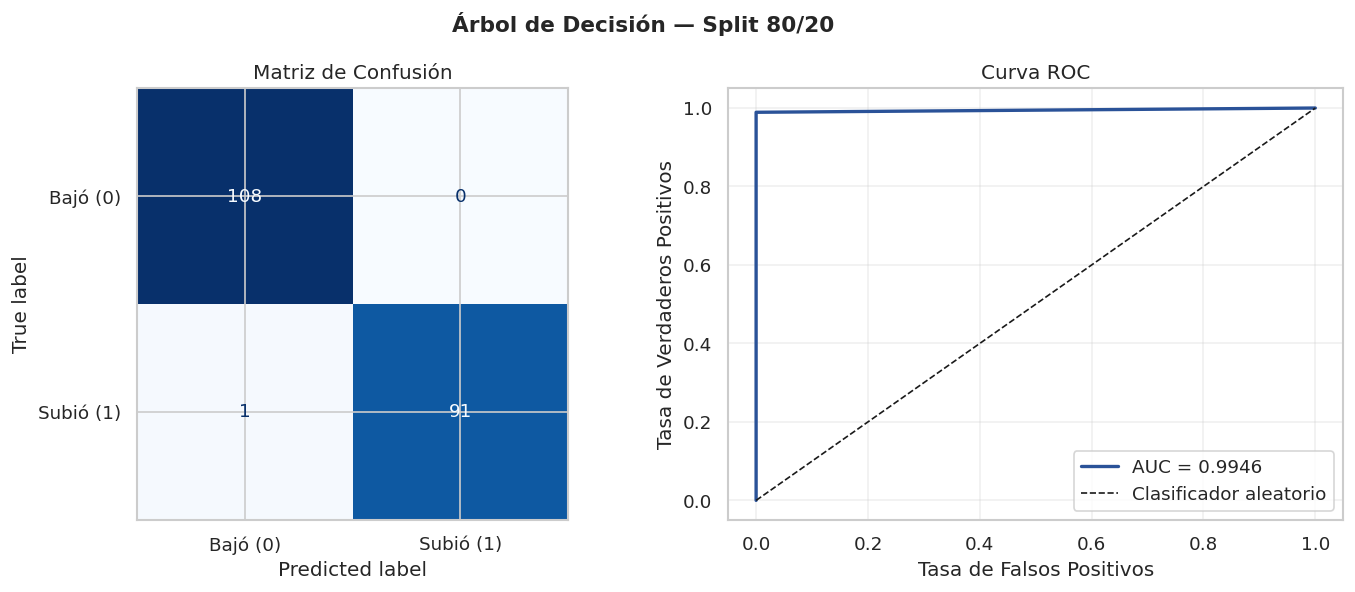

✅ Gráfica guardada en data/arbol_confusion_roc.png


In [8]:
# CELDA 5: Matriz de confusión y curva ROC — Split 80/20
r = resultados_arbol[0]  # Split 80/20

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Árbol de Decisión — Split 80/20', fontsize=13, fontweight='bold')

# Matriz de confusión
cm = confusion_matrix(r['y_test'], r['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bajó (0)', 'Subió (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión')

# Curva ROC
fpr, tpr, _ = roc_curve(r['y_test'], r['y_prob'])
axes[1].plot(fpr, tpr, color='#2a5298', linewidth=2, label=f"AUC = {r['roc_auc']:.4f}")
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Clasificador aleatorio')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curva ROC')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/arbol_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada en data/arbol_confusion_roc.png")

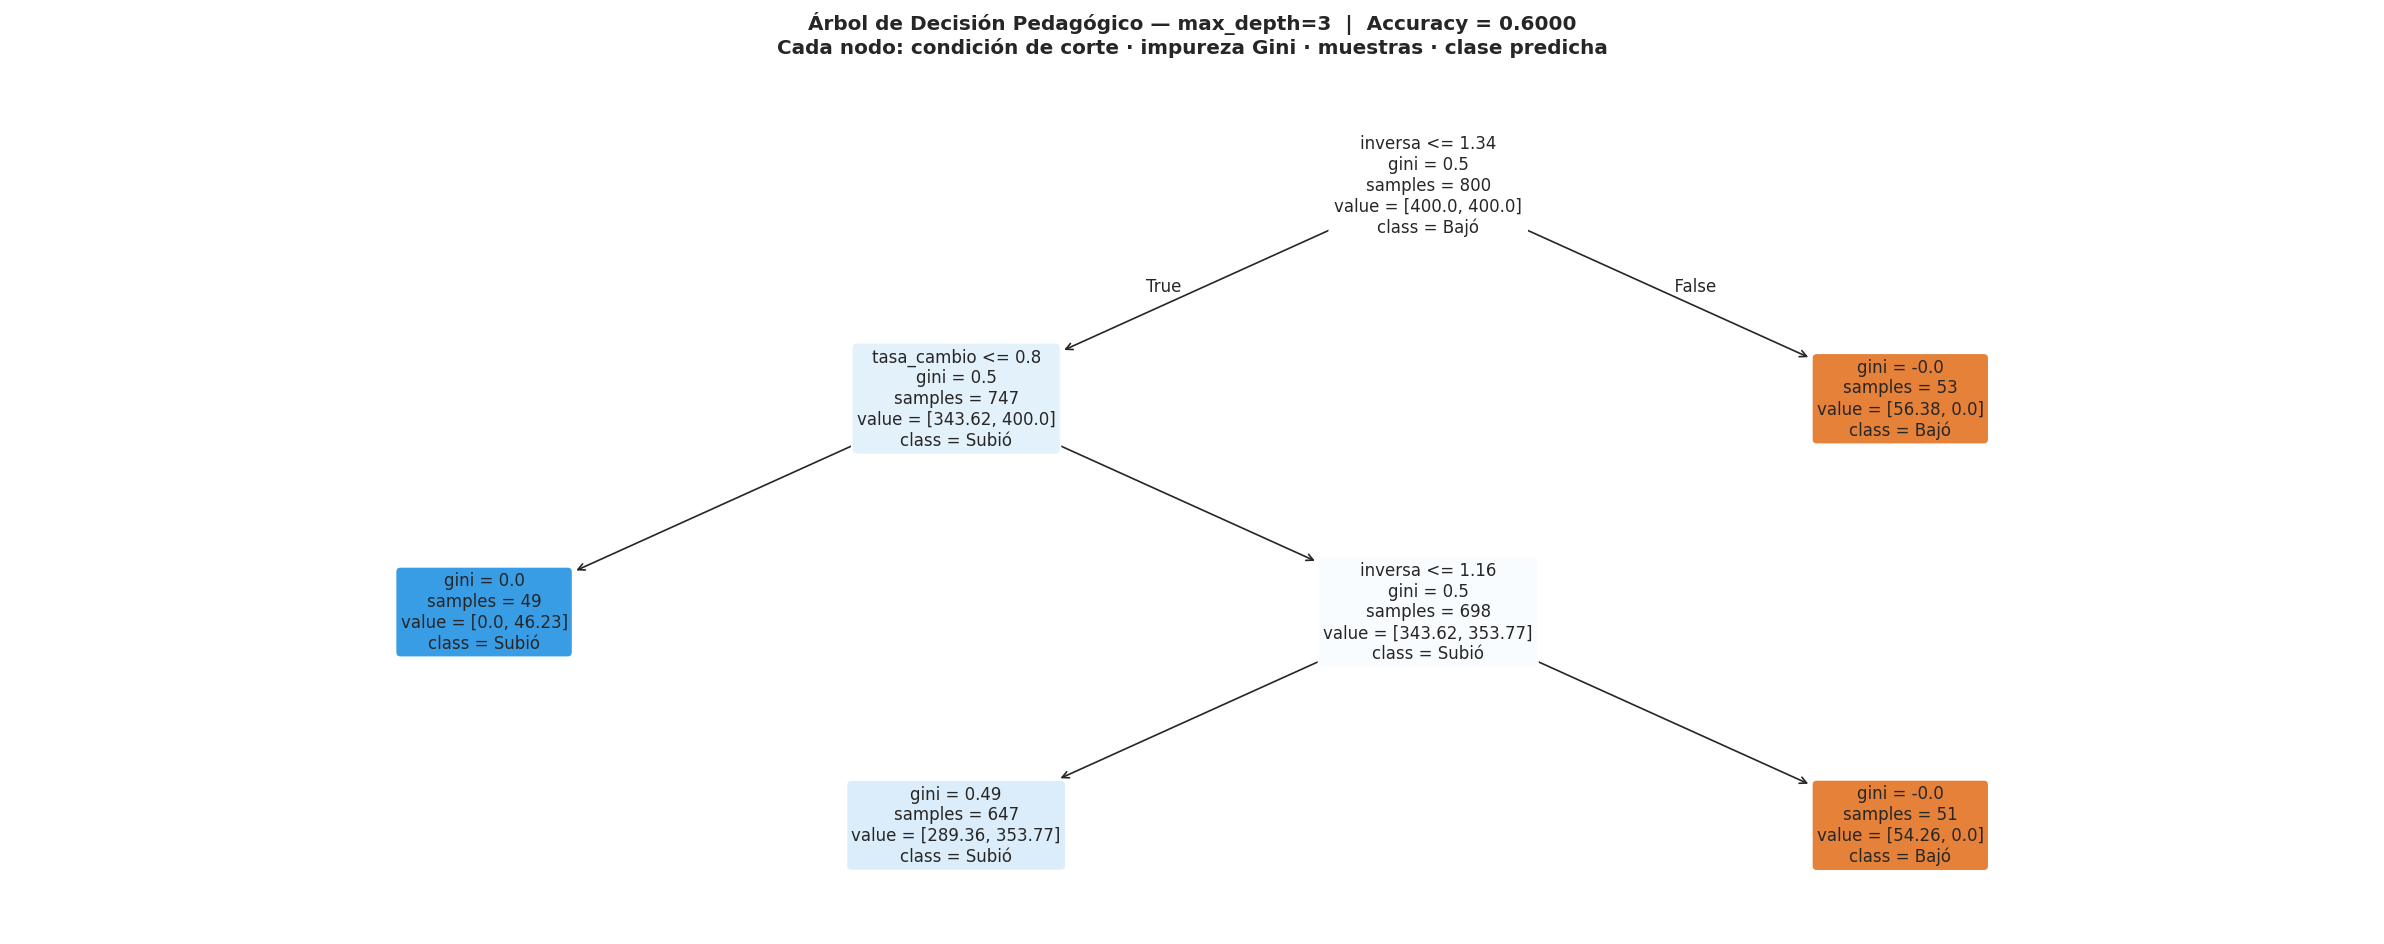


  REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=3)
|--- inversa <= 1.34
|   |--- tasa_cambio <= 0.80
|   |   |--- class: 1
|   |--- tasa_cambio >  0.80
|   |   |--- inversa <= 1.16
|   |   |   |--- class: 1
|   |   |--- inversa >  1.16
|   |   |   |--- class: 0
|--- inversa >  1.34
|   |--- class: 0



In [9]:
# CELDA 6: Árbol pedagógico (max_depth=3)
X_train_viz, X_test_viz, y_train_viz, y_test_viz = train_test_split(
    X_ext, y, test_size=0.20, random_state=42
)
modelo_viz = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
modelo_viz.fit(X_train_viz, y_train_viz)
r2_viz = accuracy_score(y_test_viz, modelo_viz.predict(X_test_viz))

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    modelo_viz,
    max_depth=3,
    feature_names=FEATURES_EXT,
    class_names=['Bajó', 'Subió'],
    filled=True,
    rounded=True,
    impurity=True,
    precision=2,
    fontsize=10,
    ax=ax
)
ax.set_title(
    f'Árbol de Decisión Pedagógico — max_depth=3  |  Accuracy = {r2_viz:.4f}\n'
    'Cada nodo: condición de corte · impureza Gini · muestras · clase predicha',
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('data/arbol_pedagogico.png', dpi=150, bbox_inches='tight')
plt.show()

# Reglas en texto
print("\n" + "="*60)
print("  REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=3)")
print("="*60)
print(export_text(modelo_viz, feature_names=FEATURES_EXT))

In [10]:
# CELDA 7: Regresión Logística — 3 splits
scaler = StandardScaler()
resultados_logistica = []

for s in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X_ext, y, test_size=s['test_size'], random_state=42
    )
    
    # Escalar (requerido para regresión logística)
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    
    modelo = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]
    
    resultados_logistica.append({
        'nombre'    : s['nombre'],
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred),
        'recall'    : recall_score(y_test, y_pred),
        'f1'        : f1_score(y_test, y_pred),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        'modelo'    : modelo,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
    })

resumen_log = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'],  4),
    'Precision'      : round(r['precision'], 4),
    'Recall'         : round(r['recall'],    4),
    'F1-Score'       : round(r['f1'],        4),
    'ROC-AUC'        : round(r['roc_auc'],   4),
} for r in resultados_logistica]).set_index('Split')

print("=" * 65)
print(f"{'REGRESIÓN LOGÍSTICA — TABLA DE MÉTRICAS':^65}")
print("=" * 65)
display(resumen_log.style
    .background_gradient(cmap='Blues', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .set_caption("Regresión Logística — Clasificación: ¿Subió la tasa?")
)

             REGRESIÓN LOGÍSTICA — TABLA DE MÉTRICAS             


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,800,200,0.5400,0.5000,0.5652,0.5306,0.5441
Split 70/30,700,300,0.5867,0.5562,0.6573,0.6026,0.5565
Split 60/40,600,400,0.5625,0.5541,0.6400,0.5940,0.5674


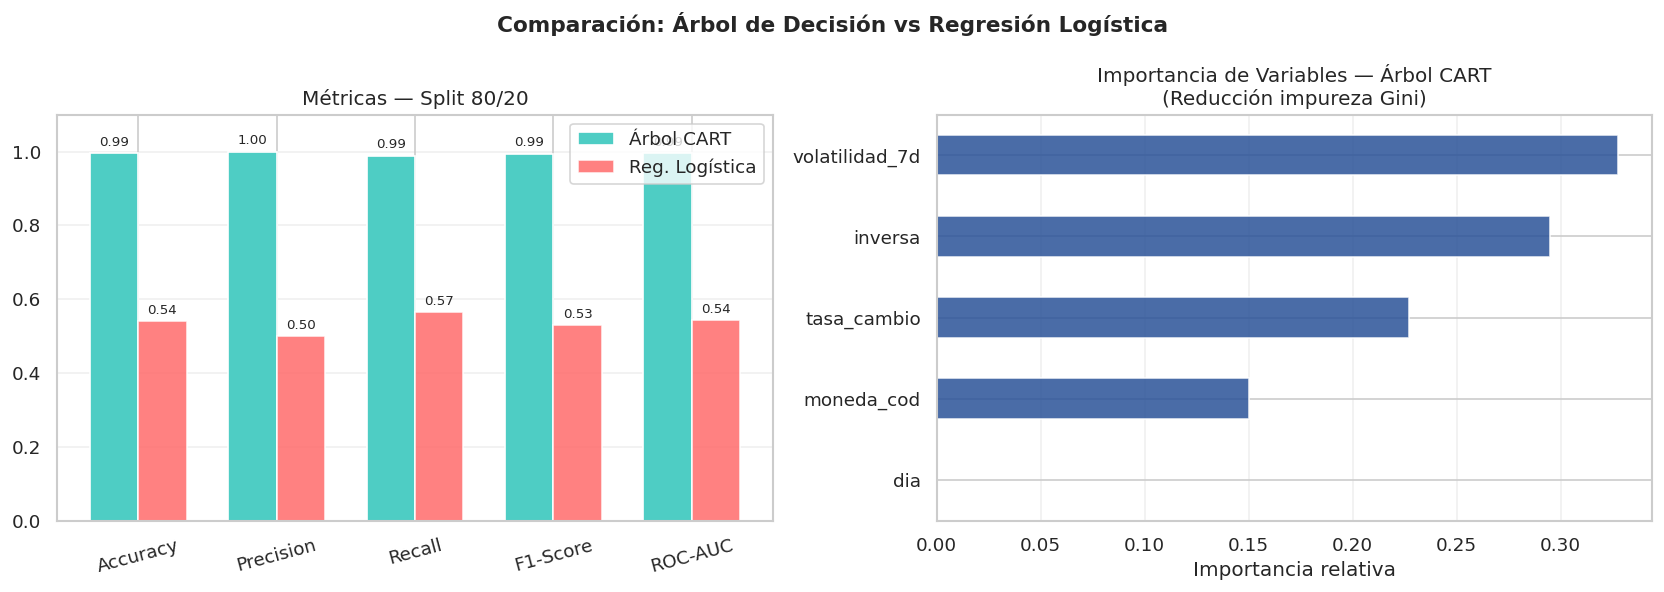


📊 IMPORTANCIA DE VARIABLES:
volatilidad_7d    0.3278
inversa           0.2950
tasa_cambio       0.2270
moneda_cod        0.1503
dia               0.0000
dtype: float64


In [11]:
# CELDA 8: Comparación final + importancia de variables
# Gráfica comparativa de métricas
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
arbol_vals   = [resumen_arbol.loc['Split 80/20', m] for m in metricas]
logist_vals  = [resumen_log.loc['Split 80/20', m] for m in metricas]

x = np.arange(len(metricas))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparación: Árbol de Decisión vs Regresión Logística', fontsize=13, fontweight='bold')

axes[0].bar(x - w/2, arbol_vals,  w, label='Árbol CART',  color='#4ecdc4')
axes[0].bar(x + w/2, logist_vals, w, label='Reg. Logística', color='#ff6b6b', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas, rotation=15)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Métricas — Split 80/20')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, (a, l) in enumerate(zip(arbol_vals, logist_vals)):
    axes[0].text(i - w/2, a + 0.02, f'{a:.2f}', ha='center', fontsize=8)
    axes[0].text(i + w/2, l + 0.02, f'{l:.2f}', ha='center', fontsize=8)

# Importancia de variables (Árbol)
modelo_final = resultados_arbol[0]['modelo']
importancias = pd.Series(modelo_final.feature_importances_, index=FEATURES_EXT).sort_values()
importancias.plot(kind='barh', ax=axes[1], color='#2a5298', alpha=0.85)
axes[1].set_title('Importancia de Variables — Árbol CART\n(Reducción impureza Gini)')
axes[1].set_xlabel('Importancia relativa')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('data/comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 IMPORTANCIA DE VARIABLES:")
print(importancias.sort_values(ascending=False).round(4))